In [1]:
import os

import cartopy.crs as ccrs
import cmcrameri as cmc  # noqa: F401
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml
from unseen_awg.plotting_utils import (
    add_headers,
    add_label_to_axes,
    map_plot_without_frame_with_bounds,
)

In [2]:
mpl.rc_file("../../matplotlibrc")
ALPHABET = "abcdefghijklmnopqrstuvwxyz"

In [3]:
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

Show biases in generated weather:
- for each season
- for each variable
- for a list of quantiles (10,25,50,75,90)
- for weather generated with ERA5 WG (to appendix) and with the Reforecast WG.

In [4]:
dir_quantiles = os.path.join(paths["dir_results"], "quantile_maps")

In [5]:
ds_names = {
    "preprocessed_impact_variables_era5/rechunk_combined_facc0e91.zarr": r"$\mathrm{ERA5}_{2003-2023}$",
    "preprocessed_impact_variables_reforecasts/combined_7d1d3d97.zarr": "Reforecasts",
    "preprocessed_impact_variables_reforecasts/combined-corrected_facc0e91_7d1d3d97_884a804a_3f7e331d.zarr": "Bias-corrected\nreforecasts",
}

In [6]:
rename_vars = {
    "t2m": r"$T_\mathrm{2m, mean}$",
    "mx2t": r"$T_\mathrm{2m, max}$",
    "mn2t": r"$T_\mathrm{2m, min}$",
    "tp": r"$P$",
}
rerename_vars = {v: k for (k, v) in rename_vars.items()}

In [7]:
confs = []
quantiles_wg = []
quantiles_gt = []

quantiles_yearly_wg = []
quantiles_yearly_gt = []

dirs_runs = [
    ("Reforecasts", "5e06172f_f40e9460_1e69bda9_d13ad10f"),
    ("Bias-corrected\nreforecasts", "5e06172f_f40e9460_1e69bda9_d13ad10f"),
    (r"$\mathrm{ERA5}_{2003-2023}$", "f3d1f2f7_6e629cd9_7560715e_d13ad10f"),
]
hashes_quantiles = ["b1b43147_36c5e357", "b1b43147_98893d89", "b1b43147_56ed41bc"]

for (ds_wg, dir_runs), hash_quantiles in zip(dirs_runs, hashes_quantiles, strict=True):
    print(ds_wg, hash_quantiles)
    for season in ["DJF", "MAM", "JJA", "SON"]:
        qs_wg = xr.open_dataset(
            os.path.join(
                dir_quantiles, dir_runs, f"{season}_{hash_quantiles}", "quantiles_wg.nc"
            )
        )
        qs_gt = xr.open_dataset(
            os.path.join(
                dir_quantiles, dir_runs, f"{season}_{hash_quantiles}", "quantiles_gt.nc"
            )
        )
        qs_yearly_wg = xr.open_dataset(
            os.path.join(
                dir_quantiles,
                dir_runs,
                f"{season}_{hash_quantiles}",
                "quantiles_yearly_wg.nc",
            )
        )
        qs_yearly_gt = xr.open_dataset(
            os.path.join(
                dir_quantiles,
                dir_runs,
                f"{season}_{hash_quantiles}",
                "quantiles_yearly_gt.nc",
            )
        )

        qs_gt = qs_gt.rename(rename_vars)
        qs_wg = qs_wg.rename(rename_vars)
        qs_yearly_gt = qs_yearly_gt.rename(rename_vars)
        qs_yearly_wg = qs_yearly_wg.rename(rename_vars)

        with open(
            os.path.join(
                dir_quantiles, dir_runs, f"{season}_{hash_quantiles}", "params.yaml"
            )
        ) as file:
            cfg = yaml.safe_load(file)

        confs.append(cfg)

        quantiles_wg.append(qs_wg.expand_dims({"ds_wg": [ds_wg]}))
        quantiles_gt.append(qs_gt.expand_dims({"ds_wg": [ds_wg]}))
        quantiles_yearly_wg.append(qs_yearly_wg.expand_dims({"ds_wg": [ds_wg]}))
        quantiles_yearly_gt.append(qs_yearly_gt.expand_dims({"ds_wg": [ds_wg]}))

Reforecasts b1b43147_36c5e357
Bias-corrected
reforecasts b1b43147_98893d89
$\mathrm{ERA5}_{2003-2023}$ b1b43147_56ed41bc


In [ ]:
seasons = {
    6: "JJA",
    9: "SON",
    12: "DJF",
    3: "MAM",
}

qs_wg_all = []
qs_gt_all = []
for qs_wg, qs_gt, cfg in zip(quantiles_wg, quantiles_gt, confs):
    print(cfg["months"])
    qs_wg_all.append(qs_wg.expand_dims({"season": [cfg["months"]]}))
    qs_gt_all.append(qs_gt.expand_dims({"season": [cfg["months"]]}))

qs_wg_all = xr.combine_by_coords(qs_wg_all, combine_attrs="drop_conflicts")
qs_gt_all = xr.combine_by_coords(qs_gt_all, combine_attrs="drop_conflicts")

qs_yearly_wg = xr.combine_by_coords(quantiles_yearly_wg, combine_attrs="drop_conflicts")
qs_yearly_gt = xr.combine_by_coords(quantiles_yearly_gt, combine_attrs="drop_conflicts")

In [ ]:
qs_wg_all.mean(("latitude", "longitude")).squeeze()[
    "$T_\mathrm{2m, mean}$"
].assign_coords(season=("season", [0, 1, 2, 3]))

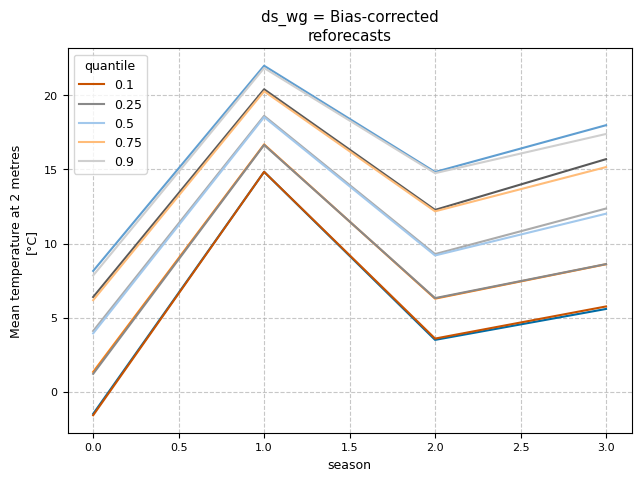

In [10]:
qs_wg_all.mean(("latitude", "longitude")).squeeze()[
    r"$T_\mathrm{2m, mean}$"
].assign_coords(season=("season", [0, 1, 2, 3])).sel(
    ds_wg="Bias-corrected\nreforecasts", sigma=2.5
).plot(x="season", hue="quantile")

qs_gt_all.mean(("latitude", "longitude")).squeeze()[r"$T_\mathrm{2m, mean}$"].sel(
    ds_wg="Bias-corrected\nreforecasts"
).assign_coords(season=("season", [0, 1, 2, 3])).plot(x="season", hue="quantile")

In [11]:
def difference_measure(a, b):
    if a.name in [
        "$T_\mathrm{2m, mean}$",
        "$T_\mathrm{2m, max}$",
        "$T_\mathrm{2m, min}$",
    ]:
        return a - b
    elif a.name == "$P$":
        return (a / b - 1) * 100
    else:
        raise ValueError(f"Unknown variable {a.name}")

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1355334/3504069895.py:3: SyntaxWarning: invalid escape sequence '\m'
  "$T_\mathrm{2m, mean}$",
/tmp/ipykernel_1355334/3504069895.py:4: SyntaxWarning: invalid escape sequence '\m'
  "$T_\mathrm{2m, max}$",
/tmp/ipykernel_1355334/3504069895.py:5: SyntaxWarning: invalid escape sequence '\m'
  "$T_\mathrm{2m, min}$",


In [12]:
cmaps = {
    "$T_\mathrm{2m, mean}$": {
        "cmap": plt.get_cmap("cmc.vik"),
        "norm": mpl.colors.TwoSlopeNorm(vmin=-20, vcenter=0, vmax=40),
        "cbar_kwargs": {
            "label": r"$T_\mathrm{2m, mean}$ [°C]",
            "orientation": "horizontal",
            "extend": "neither",
        },
    },
    "$T_\mathrm{2m, min}$": {
        "cmap": plt.get_cmap("cmc.vik"),
        "norm": mpl.colors.TwoSlopeNorm(vmin=-20, vcenter=0, vmax=40),
        "cbar_kwargs": {
            "label": r"$T_\mathrm{2m, min}$ [°C]",
            "orientation": "horizontal",
            "extend": "neither",
        },
    },
    "$T_\mathrm{2m, max}$": {
        "cmap": plt.get_cmap("cmc.vik"),
        "norm": mpl.colors.TwoSlopeNorm(vmin=-20, vcenter=0, vmax=40),
        "cbar_kwargs": {
            "label": r"$T_\mathrm{2m, max}$ [°C]",
            "orientation": "horizontal",
            "extend": "neither",
        },
    },
    "$P$": {
        "cmap": plt.get_cmap("cmc.oslo_r"),
        "norm": mpl.colors.LogNorm(vmin=1, vmax=40),
        "cbar_kwargs": {
            "label": r"$P$ [mm]",
            "orientation": "horizontal",
            "extend": "neither",
        },
    },
}

cmaps_diffs = {
    "$T_\mathrm{2m, mean}$": {
        "cmap": plt.get_cmap("cmc.vik"),
        "norm": mpl.colors.CenteredNorm(vcenter=0, halfrange=3),
        "cbar_kwargs": {
            "label": r"$Q_{q, gen} - Q_{q, ERA5}$ [K]",
            "orientation": "horizontal",
            "extend": "neither",
        },
    },
    "$T_\mathrm{2m, min}$": {
        "cmap": plt.get_cmap("cmc.vik"),
        "norm": mpl.colors.CenteredNorm(vcenter=0, halfrange=3),
        "cbar_kwargs": {
            "label": r"$Q_{q, gen} - Q_{q, ERA5}$ [K]",
            "orientation": "horizontal",
            "extend": "neither",
        },
    },
    "$T_\mathrm{2m, max}$": {
        "cmap": plt.get_cmap("cmc.vik"),
        "norm": mpl.colors.CenteredNorm(vcenter=0, halfrange=3),
        "cbar_kwargs": {
            "label": r"$Q_{q, gen} - Q_{q, ERA5}$ [K]",
            "orientation": "horizontal",
            "extend": "neither",
        },
    },
    "$P$": {
        "cmap": plt.get_cmap("cmc.broc_r"),
        "norm": mpl.colors.TwoSlopeNorm(vmin=-40, vcenter=0, vmax=40),
        "cbar_kwargs": {
            "label": r"$\frac{Q_{q, \mathrm{gen}} - Q_{q, \mathrm{ERA5}}}{Q_{q, \mathrm{ERA5}}}$ [%]",
            "orientation": "horizontal",
            "extend": "neither",
        },
    },
}

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1355334/2764791289.py:2: SyntaxWarning: invalid escape sequence '\m'
  "$T_\mathrm{2m, mean}$": {
/tmp/ipykernel_1355334/2764791289.py:11: SyntaxWarning: invalid escape sequence '\m'
  "$T_\mathrm{2m, min}$": {
/tmp/ipykernel_1355334/2764791289.py:20: SyntaxWarning: invalid escape sequence '\m'
  "$T_\mathrm{2m, max}$": {
/tmp/ipykernel_1355334/2764791289.py:41: SyntaxWarn

show ground truth absolute values and biases of other datasets: 

In [13]:
run_confs = [
    {"sigma": 4.0, "ds_wg": r"$\mathrm{ERA5}_{2003-2023}$"},
    {"sigma": 2.5, "ds_wg": "Reforecasts"},
    {"sigma": 2.5, "ds_wg": "Bias-corrected\nreforecasts"},
]

In [14]:
for var in qs_yearly_gt.data_vars:
    fig = plt.figure(figsize=(10, 10))
    gs = fig.add_gridspec(
        len(qs_yearly_wg["quantile"]) + 1,
        1 + len(qs_yearly_wg.ds_wg),
        height_ratios=[1] * len(qs_yearly_wg["quantile"]) + [0.03],
    )  # The last row is for the colorbar

    axs_cbar_wg = [
        fig.add_subplot(gs[-1, j + 1]) for j in range(len(qs_yearly_wg.ds_wg))
    ]

    ax_cbar_gt = fig.add_subplot(gs[-1, 0])
    for i, q in enumerate(qs_yearly_gt["quantile"]):
        gt = qs_yearly_gt.sel(quantile=q, ds_wg="Bias-corrected\nreforecasts")[var]

        # ground truth:
        ax = fig.add_subplot(gs[i, 0], projection=ccrs.Robinson())
        if i == 0:
            map_plot_without_frame_with_bounds(
                ax=ax,
                da=gt,
                **cmaps[var],
                cbar_ax=ax_cbar_gt,
            )
        else:
            map_plot_without_frame_with_bounds(
                ax=ax,
                da=gt,
                add_colorbar=False,
                **{k: v for k, v in cmaps[var].items() if k != "cbar_kwargs"},
            )
        ax.coastlines()
        ax.set_title("")

        for j, run_conf in enumerate(run_confs):
            wg = qs_yearly_wg.sel(**run_conf, quantile=q)[var].transpose()
            # 'error' of  WG
            ax = fig.add_subplot(gs[i, j + 1], projection=ccrs.Robinson())
            if i == 0:
                map_plot_without_frame_with_bounds(
                    ax=ax,
                    da=difference_measure(wg, gt),
                    **cmaps_diffs[var],
                    cbar_ax=axs_cbar_wg[j],
                )
            else:
                map_plot_without_frame_with_bounds(
                    ax=ax,
                    da=difference_measure(wg, gt),
                    add_colorbar=False,
                    **{k: v for k, v in cmaps_diffs[var].items() if k != "cbar_kwargs"},
                )
            ax.coastlines()
            ax.set_title("")

    font_kwargs = dict(fontweight="bold", fontsize="large")

    add_headers(
        fig,
        col_headers=["Ground Truth"]
        + [rf"$\Delta$ WG {cfg['ds_wg']}" for cfg in run_confs],
        row_headers=[f"q={q.data}" for q in qs_wg_all["quantile"]]
        + [
            "",
        ],
        col_pad=30,
        **font_kwargs,
    )
    fig.suptitle(f"{var}")
    plt.savefig(
        os.path.join(paths["dir_images"], f"quantiles_corrected-{var}-yearly.png")
    )
    plt.close()

In [15]:
for season in qs_gt_all.season:
    for var in qs_gt_all.data_vars:
        fig = plt.figure(figsize=(10, 10))
        gs = fig.add_gridspec(
            len(qs_wg_all["quantile"]) + 1,
            1 + len(qs_wg_all.ds_wg),
            height_ratios=[1] * len(qs_wg_all["quantile"]) + [0.03],
        )  # The last row is for the colorbar

        axs_cbar_wg = [
            fig.add_subplot(gs[-1, j + 1]) for j in range(len(qs_wg_all.ds_wg))
        ]

        ax_cbar_gt = fig.add_subplot(gs[-1, 0])
        for i, q in enumerate(qs_gt_all["quantile"]):
            gt = qs_gt_all.sel(
                quantile=q, ds_wg="Bias-corrected\nreforecasts", season=season
            )[var]

            # ground truth:
            ax = fig.add_subplot(gs[i, 0], projection=ccrs.Robinson())
            if i == 0:
                m = map_plot_without_frame_with_bounds(
                    ax=ax,
                    da=gt,
                    **cmaps[var],
                    cbar_ax=ax_cbar_gt,
                )
            else:
                m = map_plot_without_frame_with_bounds(
                    ax=ax,
                    da=gt,
                    add_colorbar=False,
                    **{k: v for k, v in cmaps[var].items() if k != "cbar_kwargs"},
                )
            m.set_rasterized(True)
            ax.coastlines()
            ax.set_title("")

            for j, run_conf in enumerate(run_confs):
                wg = qs_wg_all.sel(**run_conf, quantile=q, season=season)[
                    var
                ].transpose()
                # 'error' of  WG
                ax = fig.add_subplot(gs[i, j + 1], projection=ccrs.Robinson())
                if i == 0:
                    m = map_plot_without_frame_with_bounds(
                        ax=ax,
                        da=difference_measure(wg, gt),
                        **cmaps_diffs[var],
                        cbar_ax=axs_cbar_wg[j],
                    )
                else:
                    m = map_plot_without_frame_with_bounds(
                        ax=ax,
                        da=difference_measure(wg, gt),
                        add_colorbar=False,
                        **{
                            k: v
                            for k, v in cmaps_diffs[var].items()
                            if k != "cbar_kwargs"
                        },
                    )
                m.set_rasterized(True)
                ax.coastlines()
                ax.set_title("")

        font_kwargs = dict(fontweight="bold", fontsize="large")

        add_headers(
            fig,
            col_headers=["Ground Truth"]
            + [rf"$\Delta$ WG {cfg['ds_wg']}" for cfg in run_confs],
            row_headers=[f"q={q.data}" for q in qs_wg_all["quantile"]]
            + [
                "",
            ],
            col_pad=30,
            **font_kwargs,
        )
        fig.suptitle(f"{var} {season.data}")
        plt.savefig(
            os.path.join(
                paths["dir_images"], f"quantiles_corrected-{var}-{season.data}.pdf"
            ),
            dpi=300,
        )
        plt.close()

In [16]:
max_P_quantile_difference = np.full((len(qs_yearly_gt["quantile"]), 3), np.nan)
min_P_quantile_difference = np.full((len(qs_yearly_gt["quantile"]), 3), np.nan)

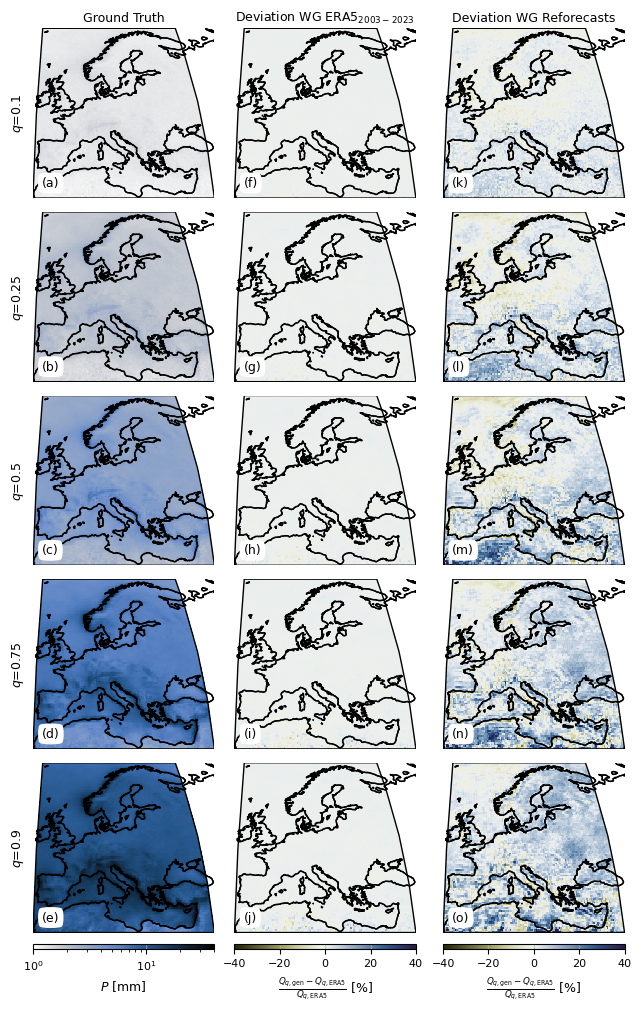

In [22]:
# Yearly precipitation only figure:

var = "$P$"  # "$T_\mathrm{2m, mean}$"  #

sel_confs = [run for run in run_confs if run["ds_wg"] != "Reforecasts"]  #

fig = plt.figure()
fig.set_figheight(10)

n_rows = len(qs_yearly_wg["quantile"]) + 1
n_cols = 1 + len(sel_confs)

gs = fig.add_gridspec(
    n_rows,
    n_cols,
    height_ratios=[1] * (n_rows - 1) + [0.03],
)  # The last row is for the colorbar

axs_cbar_wg = [fig.add_subplot(gs[-1, j + 1]) for j in range(len(sel_confs))]

ax_cbar_gt = fig.add_subplot(gs[-1, 0])
for i, q in enumerate(qs_yearly_gt["quantile"]):
    gt = qs_yearly_gt.sel(quantile=q, ds_wg="Bias-corrected\nreforecasts")[var]

    # ground truth:
    ax = fig.add_subplot(gs[i, 0], projection=ccrs.Robinson())
    if i == 0:
        m = map_plot_without_frame_with_bounds(
            ax=ax,
            da=gt,
            **cmaps[var],
            cbar_ax=ax_cbar_gt,
        )
        m.set_rasterized(True)
    else:
        m = map_plot_without_frame_with_bounds(
            ax=ax,
            da=gt,
            add_colorbar=False,
            **{k: v for k, v in cmaps[var].items() if k != "cbar_kwargs"},
        )
        m.set_rasterized(True)
    ax.coastlines()
    ax.set_title("")
    add_label_to_axes(
        ax,
        label=f"({ALPHABET[i + 0 * n_rows]})",
        ha="left",
        va="bottom",
        ax_xpos=0.05,
        ax_ypos=0.05,
    )

    for j, run_conf in enumerate(sel_confs):
        wg = qs_yearly_wg.sel(**run_conf, quantile=q)[var].transpose()
        # 'error' of  WG
        ax = fig.add_subplot(gs[i, j + 1], projection=ccrs.Robinson())
        data = difference_measure(wg, gt)
        if i == 0:
            m = map_plot_without_frame_with_bounds(
                ax=ax,
                da=data,
                **cmaps_diffs[var],
                cbar_ax=axs_cbar_wg[j],
            )
            m.set_rasterized(True)
        else:
            m = map_plot_without_frame_with_bounds(
                ax=ax,
                da=data,
                add_colorbar=False,
                **{k: v for k, v in cmaps_diffs[var].items() if k != "cbar_kwargs"},
            )
            m.set_rasterized(True)
        ax.coastlines()
        ax.set_title("")
        add_label_to_axes(
            ax,
            label=f"({ALPHABET[i + (j + 1) * (n_rows - 1)]})",
            ha="left",
            va="bottom",
            ax_xpos=0.05,
            ax_ypos=0.05,
        )
        max_P_quantile_difference[i, j] = data.max()
        min_P_quantile_difference[i, j] = data.min()

add_headers(
    fig,
    col_headers=["Ground Truth"]
    + [rf"Deviation WG {cfg['ds_wg']}" for cfg in run_confs],
    row_headers=[f"$q$={q.data}" for q in qs_wg_all["quantile"]]
    + [
        "",
    ],
)

plt.savefig(os.path.join(paths["dir_images"], "quantiles_precip_yearly.pdf"), dpi=300)

In [23]:
rows = [
    (
        "P",
        f"{np.min(min_P_quantile_difference[..., 0]):.1f}%",
        f"{np.max(max_P_quantile_difference[..., 0]):.1f}%",
    ),
    (
        "P (WG ERA5)",
        f"{np.min(min_P_quantile_difference[..., 1]):.1f}%",
        f"{np.max(max_P_quantile_difference[..., 1]):.1f}%",
    ),
]

col_width = max(len(r[0]) for r in rows)
print(f"{'Variable':<{col_width}}  {'Min':>8}  {'Max':>8}")
print("-" * (col_width + 20))
for label, mn, mx in rows:
    print(f"{label:<{col_width}}  {mn:>8}  {mx:>8}")


Variable          Min       Max
-------------------------------
P              -15.8%     17.2%
P (WG ERA5)    -37.7%     90.0%


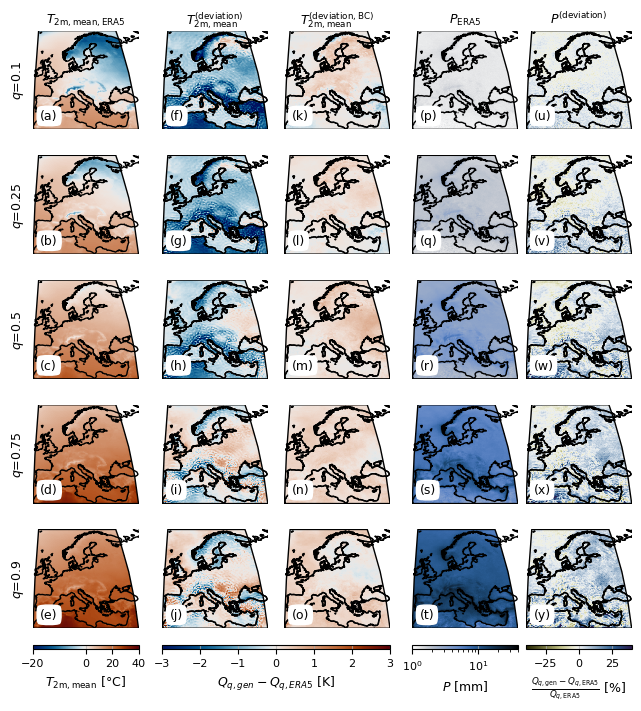

In [24]:
# combined

sel_confs_t2m = [
    run for run in run_confs if run["ds_wg"] != "$\\mathrm{ERA5}_{2003-2023}$"
]
sel_confs_t2m

sel_confs_P = [run for run in run_confs if run["ds_wg"] in ["Reforecasts"]]

max_t2m_quantile_difference = np.full((len(qs_yearly_gt["quantile"]), 2), np.nan)
min_t2m_quantile_difference = np.full((len(qs_yearly_gt["quantile"]), 2), np.nan)
max_P_quantile_difference = np.full((len(qs_yearly_gt["quantile"]), 2), np.nan)
min_P_quantile_difference = np.full((len(qs_yearly_gt["quantile"]), 2), np.nan)

fig = plt.figure()
fig.set_figheight(7)

n_rows = len(qs_yearly_wg["quantile"]) + 1
n_cols = 5

gs = fig.add_gridspec(
    n_rows,
    n_cols,
    height_ratios=[1] * (n_rows - 1) + [0.03],
)  # The last row is for the colorbar

axs_cbar = [
    fig.add_subplot(gs[-1, 0]),
    fig.add_subplot(gs[-1, 1:3]),
    fig.add_subplot(gs[-1, 3]),
    fig.add_subplot(gs[-1, 4:6]),
]

for i, q in enumerate(qs_yearly_gt["quantile"]):
    gt_t2m = qs_yearly_gt.sel(quantile=q, ds_wg="Bias-corrected\nreforecasts")[
        r"$T_\mathrm{2m, mean}$"
    ]
    gt_P = qs_yearly_gt.sel(quantile=q, ds_wg="Bias-corrected\nreforecasts")["$P$"]

    # ground truth t2m:
    ax = fig.add_subplot(gs[i, 0], projection=ccrs.Robinson())
    if i == 0:
        m = map_plot_without_frame_with_bounds(
            ax=ax,
            da=gt_t2m,
            **cmaps[r"$T_\mathrm{2m, mean}$"],
            cbar_ax=axs_cbar[0],
        )
        m.set_rasterized(True)
    else:
        m = map_plot_without_frame_with_bounds(
            ax=ax,
            da=gt_t2m,
            add_colorbar=False,
            **{
                k: v
                for k, v in cmaps[r"$T_\mathrm{2m, mean}$"].items()
                if k != "cbar_kwargs"
            },
        )
        m.set_rasterized(True)
    ax.set_title("")
    add_label_to_axes(
        ax,
        label=f"({ALPHABET[i + 0 * (n_rows - 1)]})",
        ha="left",
        va="bottom",
        ax_xpos=0.07,
        ax_ypos=0.07,
    )

    # ground truth P
    ax = fig.add_subplot(gs[i, 3], projection=ccrs.Robinson())
    if i == 0:
        m = map_plot_without_frame_with_bounds(
            ax=ax,
            da=gt_P,
            **cmaps["$P$"],
            cbar_ax=axs_cbar[2],
        )
        m.set_rasterized(True)
    else:
        m = map_plot_without_frame_with_bounds(
            ax=ax,
            da=gt_P,
            add_colorbar=False,
            **{k: v for k, v in cmaps["$P$"].items() if k != "cbar_kwargs"},
        )
        m.set_rasterized(True)
    ax.set_title("")
    add_label_to_axes(
        ax,
        label=f"({ALPHABET[i + 3 * (n_rows - 1)]})",
        ha="left",
        va="bottom",
        ax_xpos=0.07,
        ax_ypos=0.07,
    )

    for j, run_conf in enumerate(sel_confs_t2m):
        wg = qs_yearly_wg.sel(**run_conf, quantile=q)[
            r"$T_\mathrm{2m, mean}$"
        ].transpose()
        # 'error' of  WG
        ax = fig.add_subplot(gs[i, j + 1], projection=ccrs.Robinson())
        data_t2m = difference_measure(wg, gt_t2m)
        if i == 0 and j == 0:
            m = map_plot_without_frame_with_bounds(
                ax=ax,
                da=data_t2m,
                **cmaps_diffs[r"$T_\mathrm{2m, mean}$"],
                cbar_ax=axs_cbar[1],
            )
            m.set_rasterized(True)
        else:
            m = map_plot_without_frame_with_bounds(
                ax=ax,
                da=data_t2m,
                add_colorbar=False,
                **{
                    k: v
                    for k, v in cmaps_diffs[r"$T_\mathrm{2m, mean}$"].items()
                    if k != "cbar_kwargs"
                },
            )
            m.set_rasterized(True)
        ax.coastlines()
        ax.set_title("")
        add_label_to_axes(
            ax,
            label=f"({ALPHABET[i + (j + 1) * (n_rows - 1)]})",
            ha="left",
            va="bottom",
            ax_xpos=0.07,
            ax_ypos=0.07,
        )
        max_t2m_quantile_difference[i, j] = data_t2m.max()
        min_t2m_quantile_difference[i, j] = data_t2m.min()

    for j, run_conf in enumerate(sel_confs_P):
        wg = qs_yearly_wg.sel(**run_conf, quantile=q)[r"$P$"].transpose()
        # 'error' of  WG
        ax = fig.add_subplot(gs[i, j + 4], projection=ccrs.Robinson())
        data_P = difference_measure(wg, gt_P)
        if i == 0:
            m = map_plot_without_frame_with_bounds(
                ax=ax,
                da=data_P,
                **cmaps_diffs[r"$P$"],
                cbar_ax=axs_cbar[3],
            )
            m.set_rasterized(True)
        else:
            m = map_plot_without_frame_with_bounds(
                ax=ax,
                da=data_P,
                add_colorbar=False,
                **{k: v for k, v in cmaps_diffs[r"$P$"].items() if k != "cbar_kwargs"},
            )
            m.set_rasterized(True)
        ax.coastlines()
        ax.set_title("")
        add_label_to_axes(
            ax,
            label=f"({ALPHABET[i + (j + 4) * (n_rows - 1)]})",
            ha="left",
            va="bottom",
            ax_xpos=0.07,
            ax_ypos=0.07,
        )
        max_P_quantile_difference[i, j] = data_P.max()
        min_P_quantile_difference[i, j] = data_P.min()


add_headers(
    fig,
    col_headers=[
        r"$T_\mathrm{2m, mean, ERA5}$",
        r"$T_\mathrm{2m, mean}^{(\mathrm{deviation})}$",
        r"$T_\mathrm{2m, mean}^{(\mathrm{deviation, BC})}$",
        r"$P_\mathrm{ERA5}$",
        r"$P^{(\mathrm{deviation})}$",
        r"$P^{(\mathrm{deviation, BC})}$",
    ],
    row_headers=[f"$q$={q.data}" for q in qs_wg_all["quantile"]]
    + [
        "",
    ],
)


plt.savefig(os.path.join(paths["dir_images"], "quantiles_yearly_summary.pdf"), dpi=300)

In [25]:
rows = [
    (
        "P",
        f"{np.min(min_P_quantile_difference):.1f}%",
        f"{np.max(max_P_quantile_difference):.1f}%",
    ),
    (
        "t2m",
        f"{np.min(min_t2m_quantile_difference[..., 0]):.1f}K",
        f"{np.max(max_t2m_quantile_difference[..., 0]):.1f}K",
    ),
    (
        "t2m (bias corrected)",
        f"{np.min(min_t2m_quantile_difference[..., 1]):.1f}K",
        f"{np.max(max_t2m_quantile_difference[..., 1]):.1f}K",
    ),
]

col_width = max(len(r[0]) for r in rows)
print(f"{'Variable':<{col_width}}  {'Min':>8}  {'Max':>8}")
print("-" * (col_width + 20))
for label, mn, mx in rows:
    print(f"{label:<{col_width}}  {mn:>8}  {mx:>8}")


Variable                   Min       Max
----------------------------------------
P                         nan%      nan%
t2m                      -6.1K      4.0K
t2m (bias corrected)     -1.4K      1.8K
